In [ ]:
#Задача. Выяснить отсев студента
import pandas as pd
stInfo=pd.read_csv(r'\Users\РЗ\Desktop\practice\StudentLearningDataset\studentInfo.csv')
#stInfo

In [46]:
print(stInfo.head())

  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1               60          N         Pass  

In [47]:
stInfo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


In [ ]:
#Очистка данных. 1)Видим количество пустых ячеек, сколько пустых ячеек. Если пустых ячеек мало где-то 15-30 то удаляем строки функцией dropna(), если много то добавляем значение Unknown функцией fillna().
stInfo.isnull().sum()

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

In [ ]:
#Очистка данных. Заполняем пустые ячейки в столбце imd_band значением Unknown.Потому что в столбце imd_band много пустых ячеек, поэтому заполняем Unknown. Если бы было мало пустых ячеек, то удаляли бы строки с пустыми ячейками.
stInfo['imd_band']=stInfo['imd_band'].fillna('Unknown')

In [ ]:
#Создаем новый столбец dropout, который будет содержать 1, если студент отчислен (final_result == 'Withdrawn'), и 0 в противном случае. Это позволит нам использовать этот столбец как целевую переменную для модели машинного обучения.
stInfo['dropout']=(stInfo['final_result']=='Withdrawn').astype(int)
print(stInfo['dropout'].value_counts())

dropout
0    22437
1    10156
Name: count, dtype: int64


In [ ]:
#Кодируем категориальные переменные с помощью one-hot encoding. Это создаст новые столбцы для каждой категории в указанных столбцах, где значение будет 1, если студент принадлежит к этой категории, и 0 в противном случае. Параметр drop_first=True удаляет первый столбец для каждой категории, чтобы избежать мультиколлинеарности.
StInfoEncoded=pd.get_dummies(stInfo, columns=['gender','region','highest_education','age_band',
                                               'imd_band','code_module','code_presentation','disability','final_result'], drop_first=True)

In [ ]:
#После кодирования категориальных переменных, выводим размерность закодированного DataFrame
print(StInfoEncoded.shape)

(32593, 46)


In [ ]:
StInfoEncoded.dtypes

In [54]:
#создание логистической модели
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
X=StInfoEncoded.drop(columns=['dropout','id_student','code_presentation_2014J','final_result_Fail','final_result_Pass','final_result_Withdrawn','disability_Y','imd_band_10-20','imd_band_20-30%'])
y=StInfoEncoded['dropout']
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.72      0.94      0.82      4546
           1       0.56      0.17      0.26      1973

    accuracy                           0.71      6519
   macro avg       0.64      0.55      0.54      6519
weighted avg       0.67      0.71      0.65      6519



In [ ]:
#Вывод имя столбцов в виде списка
StInfoEncoded.columns.tolist()

In [56]:
#метод случайный лес
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.73      0.81      0.77      4546
           1       0.41      0.30      0.35      1973

    accuracy                           0.66      6519
   macro avg       0.57      0.56      0.56      6519
weighted avg       0.63      0.66      0.64      6519



In [ ]:
#После применения методов логистической и случайного леса, recall и f1-score вышли очень низкими. Это означаеть что модель пропускает положительные примеры(83%). Поэтому применяем метод балансировки классов. 
# Параметр class_weight='balanced' в LogisticRegression автоматически взвешивает классы, чтобы компенсировать дисбаланс в данных.
model_balanced=LogisticRegression(max_iter=1000,class_weight='balanced')
model_balanced.fit(X_train,y_train)
y_pred_balanced=model_balanced.predict(X_test)
print(classification_report(y_test,y_pred_balanced))
      

              precision    recall  f1-score   support

           0       0.78      0.61      0.69      4546
           1       0.41      0.61      0.49      1973

    accuracy                           0.61      6519
   macro avg       0.59      0.61      0.59      6519
weighted avg       0.67      0.61      0.63      6519



In [ ]:
# Используем балансировкудля модели  случайный лес.
rf_balanced=RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
rf_balanced.fit(X_train,y_train)
y_pred_rf_balanced=rf_balanced.predict(X_test)
print(classification_report(y_test, y_pred_rf_balanced))

              precision    recall  f1-score   support

           0       0.73      0.74      0.74      4546
           1       0.39      0.37      0.38      1973

    accuracy                           0.63      6519
   macro avg       0.56      0.56      0.56      6519
weighted avg       0.63      0.63      0.63      6519



In [63]:
rf_balanced2=RandomForestClassifier(n_estimators=200, max_depth=10,class_weight='balanced_subsample',random_state=42)
rf_balanced2.fit(X_train,y_train)
y_pred_rf2=rf_balanced2.predict(X_test)
print(classification_report(y_test, y_pred_rf2))

              precision    recall  f1-score   support

           0       0.78      0.62      0.69      4546
           1       0.41      0.60      0.48      1973

    accuracy                           0.62      6519
   macro avg       0.59      0.61      0.59      6519
weighted avg       0.67      0.62      0.63      6519



                                 feature  importances
1                        studied_credits     0.277416
34                       code_module_GGG     0.102159
30                       code_module_CCC     0.081205
16  highest_education_Lower Than A Level     0.058281
0                   num_of_prev_attempts     0.030212
35               code_presentation_2013J     0.029566
31                       code_module_DDD     0.028685
19                        age_band_35-55     0.028525
2                               gender_M     0.025709
36               code_presentation_2014B     0.023907
15    highest_education_HE Qualification     0.020141
28                      imd_band_Unknown     0.018394
12                          region_Wales     0.018127
8                        region_Scotland     0.017434
27                      imd_band_90-100%     0.015928


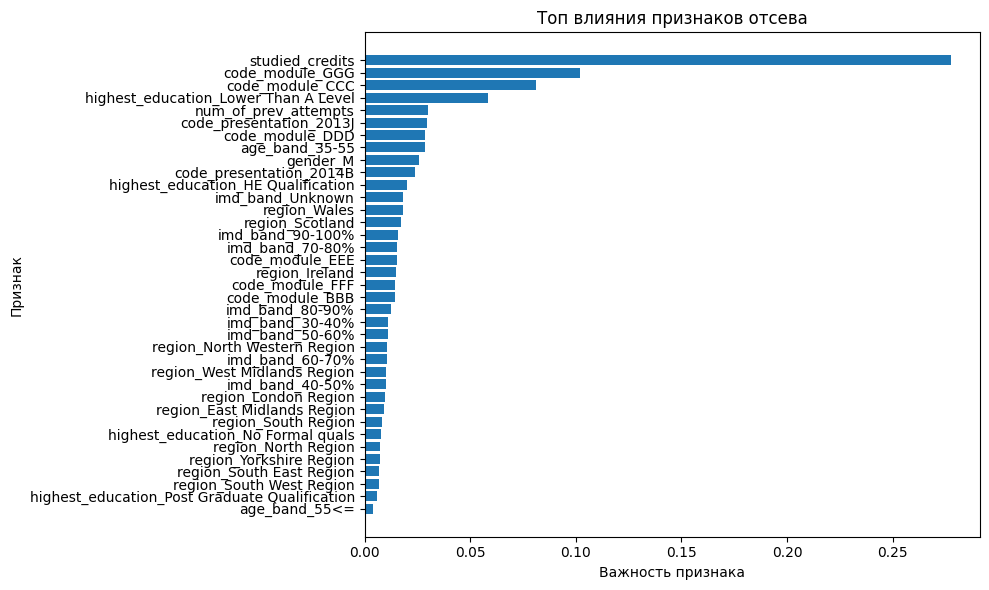

In [ ]:
#Feature-importance покажет какие признаки сильнее всего влияют на предсказание отсева
#Для Random Forest
import matplotlib.pyplot as plt
importances=rf_balanced2.feature_importances_
feature_names=X_train.columns
feat_importance_df=pd.DataFrame({
    'feature':feature_names,
    'importances':importances
}).sort_values('importances',ascending=False)
print(feat_importance_df.head(15))
plt.figure(figsize=(10,6))
plt.barh(feat_importance_df['feature'],feat_importance_df['importances'])
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.title('Топ влияния признаков отсева')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
#Для логистической регрессии(Коэффициенты)
coefficients=model_balanced.coef_[0]
feature_names=X_train.columns
coef_df=pd.DataFrame({
    'feature':feature_names,
    'coefficient':coefficients
}).sort_values('coefficient',key=abs,ascending=False)
print(coef_df.head(15))

                                 feature  coefficient
30                       code_module_CCC     1.331928
28                      imd_band_Unknown    -0.930945
31                       code_module_DDD     0.856013
17     highest_education_No Formal quals     0.643684
33                       code_module_FFF     0.550253
32                       code_module_EEE     0.504791
29                       code_module_BBB     0.461830
27                      imd_band_90-100%    -0.430582
34                       code_module_GGG    -0.424469
16  highest_education_Lower Than A Level     0.402621
25                       imd_band_70-80%    -0.388113
12                          region_Wales    -0.376419
26                       imd_band_80-90%    -0.331450
4                         region_Ireland    -0.304018
23                       imd_band_50-60%    -0.289502
